In [2]:
from models.Arima import MyArima
from models.LSTM import MyLSTM
from models.GRU import MyGRU
from models.Prophet import MyProphet
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
df = yf.download('BTC-USD', start='2019-01-01', end='2021-12-31')
test_data = yf.download('BTC-USD', start='2022-01-01', end='2022-04-01')
data = df[['Close']].values
actual_prices = test_data[['Close']].values
length = len(actual_prices)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


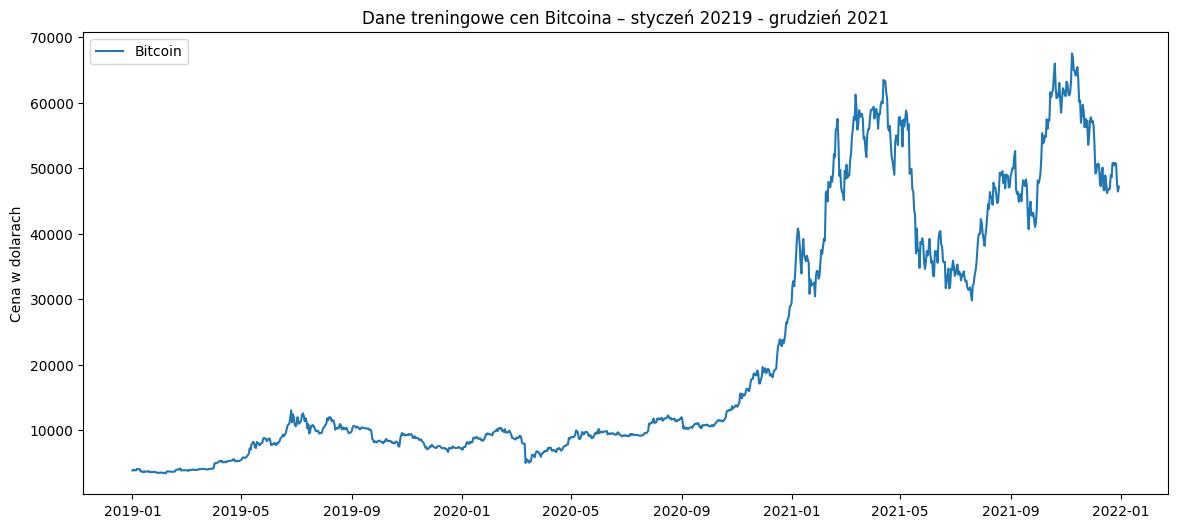

In [4]:
plt.figure(figsize=(14,6))
plt.plot(df.index, data, label="Bitcoin")
plt.title("Dane treningowe cen Bitcoina – styczeń 20219 - grudzień 2021")
plt.ylabel('Cena w dolarach')
plt.legend()
plt.savefig('dane_treningowe.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
gru_model = MyGRU(epochs=5, look_back=60)
gru_model.create_model()
gru_model.fit(data)

lstm_model = MyLSTM(epochs=5, look_back=60)
lstm_model.create_model()
lstm_model.fit(data)

Epoch 1/5


C:\Users\Michał\Desktop\crypto\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - loss: 0.0166 - val_loss: 0.0472
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 7.0677e-04 - val_loss: 0.0042
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 4.5605e-04 - val_loss: 0.0021
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 4.7746e-04 - val_loss: 0.0031
Epoch 1/5


C:\Users\Michał\Desktop\crypto\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0191 - val_loss: 0.0074
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0020 - val_loss: 0.0314
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0011 - val_loss: 0.0556
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 8.5324e-04 - val_loss: 0.0253
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 8.0700e-04 - val_loss: 0.0276


In [12]:
total_dataset = np.concatenate((data, actual_prices), axis=0)
print(length)
predicted_prices_gru = gru_model.predict(total_dataset, length, noise_level=0.5, noise_start=70)
predicted_prices_lstm = lstm_model.predict(total_dataset, length, noise_level=0.4, noise_start=70)

90
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [7]:
start_date = datetime.strptime('2022-01-01', '%Y-%m-%d')
end_date = datetime.strptime('2022-04-01', '%Y-%m-%d')
periods = (end_date - start_date).days

prophet_model = MyProphet()
prophet_model.create_model()
prophet_model.fit(df)
predictions = prophet_model.predict(periods)

11:28:49 - cmdstanpy - INFO - Chain [1] start processing
11:28:50 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
arima_model = MyArima(interval=80)
arima_model.fit(df)
forecast_dates = pd.date_range(start='2022-01-01', end='2022-03-31')
forecast_length = len(forecast_dates)
arima_predictions = arima_model.predict(forecast_length, forecast_dates)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


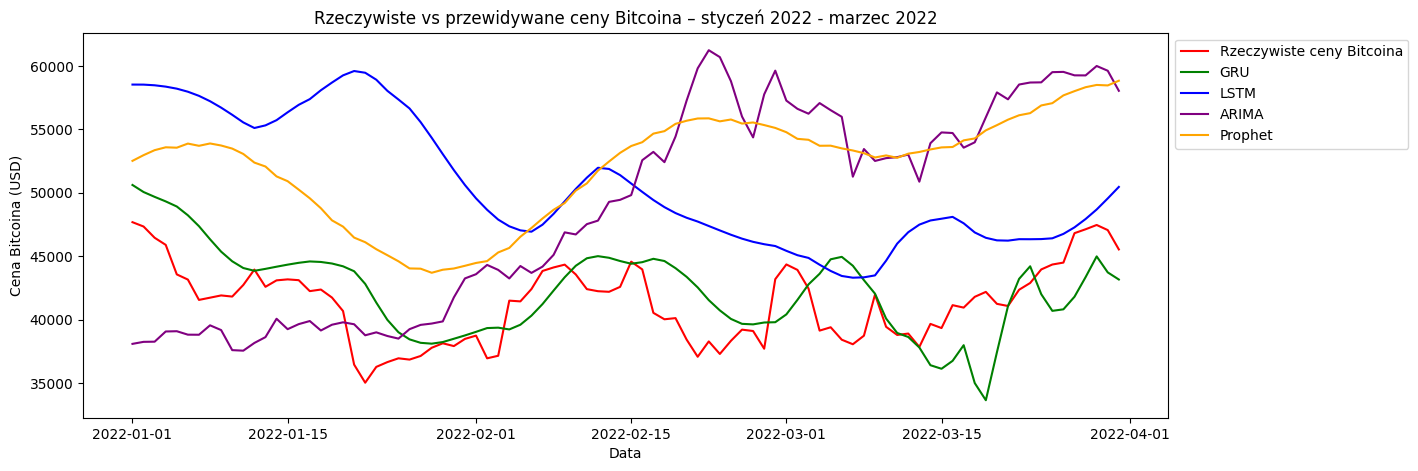

In [33]:
total_dataset = np.concatenate((data, actual_prices), axis=0)
predicted_prices_gru = gru_model.predict(total_dataset, length, noise_level=0.4, noise_start=120)
predicted_prices_lstm = lstm_model.predict(total_dataset, length, noise_level=0.4, noise_start=70)
plt.figure(figsize=(14,5))
plt.plot(test_data.index,test_data["Close"], color='red', label='Rzeczywiste ceny Bitcoina')
plt.plot(test_data.index,predicted_prices_gru, color='green', label='GRU')
plt.plot(test_data.index,predicted_prices_lstm, color='blue', label='LSTM')
plt.plot(arima_predictions, color='purple', label='ARIMA')
plt.plot(test_data.index,predictions['yhat'], label='Prophet', color='orange')
plt.title('Rzeczywiste vs przewidywane ceny Bitcoina – styczeń 2022 - marzec 2022')
plt.xlabel('Data')
plt.ylabel('Cena Bitcoina (USD)')
# plt.legend(loc='best')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('wyniki_1.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
test_data_0 = test_data["Close"].iloc[0][0]
arima_predictions_0 = arima_predictions.iloc[0][0]
arima_bias = arima_predictions_0 - test_data_0
for i in range(len(arima_predictions)):
    arima_predictions.iloc[i] = int(arima_predictions.iloc[i]) - arima_bias


prophet_predictions_0 = float(predictions['yhat'].iloc[0])
prophet_bias = prophet_predictions_0 - test_data_0
for i in range(len(predictions)):
    predictions['yhat'].iloc[i] = float(predictions['yhat'].iloc[i]) - prophet_bias

gru_predictions_0 = float(predicted_prices_gru[0])
gru_bias = gru_predictions_0 - test_data_0
for i in range(len(predicted_prices_gru)):
   predicted_prices_gru[i]  = predicted_prices_gru[i] - gru_bias

lstm_predictions_0 = float(predicted_prices_lstm[0])
lstm_bias = lstm_predictions_0 - test_data_0
for i in range(len(predicted_prices_lstm)):
   predicted_prices_lstm[i]  = predicted_prices_lstm[i] - lstm_bias

C:\Users\Michał\AppData\Local\Temp\ipykernel_22680\1002117860.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_data_0 = test_data["Close"].iloc[0][0]
C:\Users\Michał\AppData\Local\Temp\ipykernel_22680\1002117860.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arima_predictions_0 = arima_predictions.iloc[0][0]
C:\Users\Michał\AppData\Local\Temp\ipykernel_22680\1002117860.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  arima_predictions.iloc[i] = int(arima_predictions.iloc[i]) - arima_bias
C:\Users\Michał\AppD

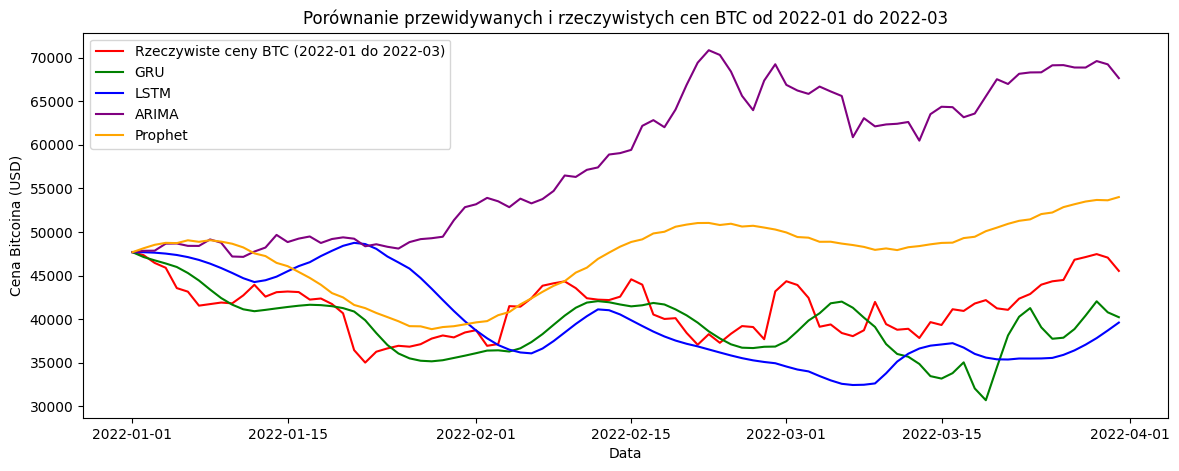

In [35]:
plt.figure(figsize=(14,5))
plt.plot(test_data.index,test_data["Close"], color='red', label='Rzeczywiste ceny BTC (2022-01 do 2022-03)')
plt.plot(test_data.index,predicted_prices_gru, color='green', label='GRU')
plt.plot(test_data.index,predicted_prices_lstm, color='blue', label='LSTM')
plt.plot(arima_predictions, color='purple', label='ARIMA')
plt.plot(test_data.index,predictions['yhat'], label='Prophet', color='orange')
plt.title('Porównanie przewidywanych i rzeczywistych cen BTC od 2022-01 do 2022-03')
plt.xlabel('Data')
plt.ylabel('Cena Bitcoina (USD)')
plt.legend(loc='upper left')
plt.savefig('wyniki_bias_1.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

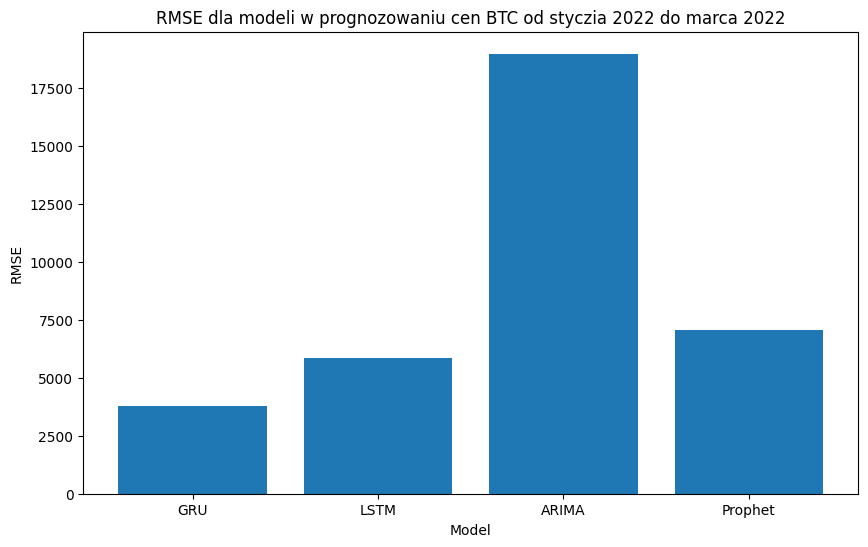

In [36]:
from sklearn.metrics import mean_squared_error

rmse_gru = np.sqrt(mean_squared_error(test_data["Close"], predicted_prices_gru))
rmse_lstm = np.sqrt(mean_squared_error(test_data["Close"], predicted_prices_lstm))
rmse_arima = np.sqrt(mean_squared_error(test_data["Close"], arima_predictions))
rmse_prophet = np.sqrt(mean_squared_error(test_data["Close"], predictions['yhat']))

# Przygotowanie danych do wykresu
model_names = ['GRU', 'LSTM', 'ARIMA', 'Prophet']
rmse_values = [rmse_gru, rmse_lstm, rmse_arima, rmse_prophet]

# Tworzenie wykresu kolumnowego
plt.figure(figsize=(10, 6))
plt.bar(model_names, rmse_values)
plt.title('RMSE dla modeli w prognozowaniu cen BTC od styczia 2022 do marca 2022')
plt.xlabel('Model')
plt.ylabel('RMSE')

# Dodanie wartości RMSE nad słupkami
# for i, value in enumerate(rmse_values):
#     plt.text(i, value + 0.01, f'{value:.2f}', ha='center', fontsize=10)
plt.savefig('RMSE_1.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


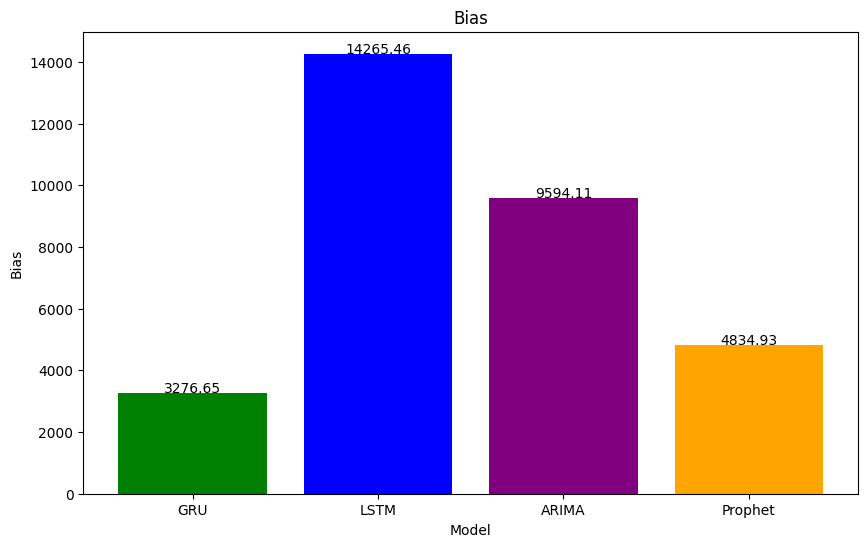

In [39]:
model_names = ['GRU', 'LSTM', 'ARIMA', 'Prophet']
bias_values = [gru_bias, lstm_bias, arima_bias, prophet_bias]
bias_values = [abs(value) for value in bias_values]
# Tworzenie wykresu kolumnowego
plt.figure(figsize=(10, 6))
plt.bar(model_names, bias_values, color=['green', 'blue', 'purple', 'orange'])
plt.title('Bias')
plt.xlabel('Model')
plt.ylabel('Bias')

# Dodanie wartości RMSE nad słupkami
for i, value in enumerate(bias_values):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center', fontsize=10)
plt.savefig('BIAS_1.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
bias_values = [gru_bias, lstm_bias, arima_bias, prophet_bias]
print(bias_values)

[np.float64(684.47265625), np.float64(0.0), np.float64(-9594.106286879469), np.float64(4834.927105574592)]


In [44]:
print(predicted_prices_gru) # GRU po odjęciu biasu

[[47686.812]
 [47183.617]
 [46817.688]
 [46463.953]
 [46085.836]
 [45484.453]
 [44729.867]
 [43820.88 ]
 [42951.668]
 [42240.793]
 [41704.74 ]
 [41427.23 ]
 [41473.652]
 [41576.35 ]
 [41695.625]
 [41824.67 ]
 [41925.87 ]
 [41915.727]
 [41827.027]
 [41648.223]
 [41325.188]
 [40498.582]
 [39245.39 ]
 [38038.062]
 [37105.254]
 [36510.953]
 [36174.617]
 [36038.957]
 [36081.992]
 [36262.75 ]
 [36474.492]
 [36737.85 ]
 [37016.297]
 [37073.633]
 [36979.535]
 [37271.94 ]
 [37862.695]
 [38640.188]
 [39566.2  ]
 [40503.484]
 [41345.918]
 [41938.773]
 [42178.24 ]
 [42162.586]
 [42003.324]
 [41821.113]
 [41904.246]
 [42110.496]
 [41980.824]
 [41530.375]
 [40954.207]
 [40237.39 ]
 [39371.184]
 [38627.582]
 [37987.78 ]
 [37574.836]
 [37443.516]
 [37504.25 ]
 [37517.137]
 [38000.61 ]
 [38936.055]
 [39994.81 ]
 [40789.168]
 [40914.58 ]
 [40604.457]
 [34744.953]
 [30464.238]
 [29123.22 ]
 [31745.955]
 [34731.926]
 [36835.99 ]
 [41971.707]
 [45030.637]
 [48866.1  ]
 [50144.473]
 [49616.926]
 [48164.695]

In [45]:
print(predicted_prices_lstm) # LSTM po odjeciu biasu

[[47686.812]
 [47709.258]
 [47677.105]
 [47587.477]
 [47439.996]
 [47210.973]
 [46896.688]
 [46485.734]
 [45991.582]
 [45438.086]
 [44849.742]
 [44587.348]
 [44478.28 ]
 [44429.453]
 [44388.188]
 [44723.773]
 [44939.63 ]
 [45041.414]
 [45015.844]
 [43817.34 ]
 [42304.04 ]
 [40637.92 ]
 [38964.24 ]
 [37407.566]
 [36049.492]
 [34935.44 ]
 [33347.766]
 [31727.246]
 [30291.719]
 [29109.61 ]
 [28277.895]
 [27828.836]
 [27748.758]
 [27964.844]
 [28208.395]
 [28258.738]
 [28679.105]
 [29378.762]
 [30316.078]
 [31760.105]
 [33436.887]
 [35160.   ]
 [36813.027]
 [38280.67 ]
 [39505.273]
 [40473.734]
 [41224.383]
 [41783.574]
 [42134.65 ]
 [42285.22 ]
 [42261.19 ]
 [42072.3  ]
 [41989.844]
 [41885.39 ]
 [41118.215]
 [40060.707]
 [38778.047]
 [37404.49 ]
 [36106.74 ]
 [35127.984]
 [34523.26 ]
 [34878.414]
 [35759.418]
 [36857.9  ]
 [37739.637]
 [38400.65 ]
 [38828.254]
 [38258.85 ]
 [37893.285]
 [37533.105]
 [37777.99 ]
 [38275.305]
 [38837.344]
 [39364.47 ]
 [39634.215]
 [39740.863]
 [39732.387]

In [46]:
print(arima_predictions) # arima po bias

               Predicted
2022-01-01  47686.106287
2022-01-02  47845.106287
2022-01-03  47858.106287
2022-01-04  48662.106287
2022-01-05  48683.106287
...                  ...
2022-03-27  68858.106287
2022-03-28  68852.106287
2022-03-29  69596.106287
2022-03-30  69220.106287
2022-03-31  67639.106287

[90 rows x 1 columns]


In [47]:
print(predictions['yhat'])

0     47686.812500
1     48135.722812
2     48529.537326
3     48756.147850
4     48725.095961
          ...     
85    53183.571225
86    53493.535181
87    53672.565432
88    53634.483975
89    54004.080784
Name: yhat, Length: 90, dtype: float64


In [1]:
plt.plot(predicted_prices_lstm)
plt.show()

NameError: name 'plt' is not defined